**Part 1a — API Fundamentals** (1 of 4)
**[Part 1a — API Fundamentals](part1a_fndmntl_api.ipynb)** | [Part 1b — Prompting, Tools & RAG](part1b_fndmntl_prompting_tools_rag.ipynb) | [Part 2a — Advanced Features & MCP](part2a_advncd_features_mcp.ipynb) | [Part 2b — MCP Transport, Claude Code & Agents](part2b_advncd_mcp_claude_code_agents.ipynb)

# Class 40.1 : CLAUDE CERTIFIED ARCHITECT
- https://anthropic.skilljar.com/

## 40.1.1) Claude API Fundamentals

### 40.1.1  a) Using Claude API


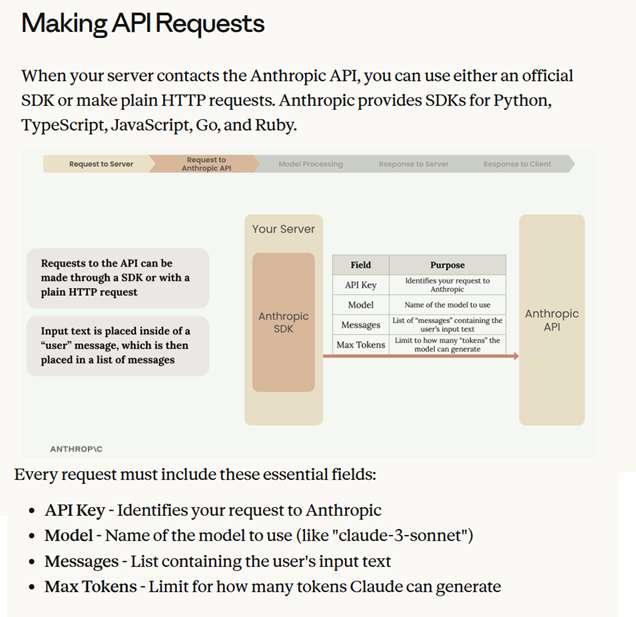

In [14]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"30px"}; margin-top: 1px;'>{"how_api_works"}</h3></div>"""))
display(Image(filename='Reference_Photos/how_api_works.png', embed=True))

- The 'your server' above is actually the server that you implement -- and it will have your own rules etc
- You server can optionally also use "Antropic SDK" which can help in managing state, agentic interactions, etc
    - Using "Anthropic SDK" is optional - you can use something else also ... or you can also implement your own pythonic implementation. Anything that is happening inside your server is fully in your control

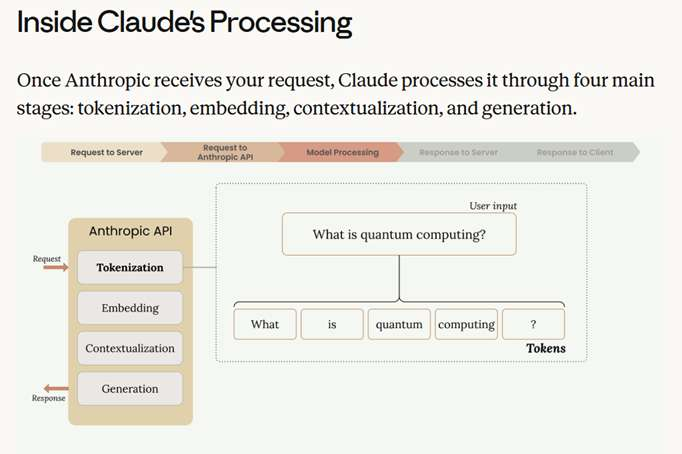

In [15]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"30px"}; margin-top: 1px;'>{"inside_api"}</h3></div>"""))
display(Image(filename='Reference_Photos/how_api_works_2.png', embed=True))

- Inside the anthropic api -- there are 4 broad steps that happens : 
    1. Tokenizaiton : Converting words in sentence to tokens
    2. Embedding : Mapping tokens in the vector space
    3. <font color="red"><b>Contextualization :</b></font> **Same word can have different embedding depending on the words surrounding it. So in contextualization the adjacent words are used to adjust the embedding - so that we have the correct representation of the word in the vector space.**
    4. **Generation :** Generating the next word. <font color="red"><b>This can be controlled by temperature.</b></font> Details in a later section

In [1]:
# Installing dependencies
%pip install anthropic python-dotenv

  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
   ---------------------------------------- 0.0/621.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/621.2 kB ? eta -:--:--
    --------------------------------------- 10.2/621.2 kB ? eta -:--:--
   --- ------------------------------------ 61.4/621.2 kB 1.1 MB/s eta 0:00:01
   ----- ---------------------------------- 92.2/621.2 kB 1.1 MB/s eta 0:00:01
   ------- ------------------------------ 122.9/621.2 kB 901.1 kB/s eta 0:00:01
   -------- ----------------------------- 143.4/621.2 kB 944.1 kB/s eta 0:00:01
   ---------- --------------------------- 174.1/621.2 kB 748.1 kB/s eta 0:00:01
   ------------- ------------------------ 225.3/621.2 kB 765.3 kB/s eta 0:00:01
   --------------- ---------------------- 245.8/621.2 kB 718.0 kB/s eta 0:00:01
   --------------- ---------------------- 256.0/621.2 kB 714.4 kB/s eta 0:00:01
   ------------------ ------------------- 307.2/621.2 kB 703.7 kB/s eta 0

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlflow 2.20.0 requires pyarrow<19,>=4.0.0, but you have pyarrow 19.0.0 which is incompatible.
streamlit 1.32.0 requires packaging<24,>=16.8, but you have packaging 24.2 which is incompatible.
streamlit 1.32.0 requires tenacity<9,>=8.1.0, but you have tenacity 9.0.0 which is incompatible.


In [ ]:
# Next added a .env file in the folder with Anthropic api key

In [1]:
# Load the api key from the .env file
from dotenv import load_dotenv
load_dotenv()

# Create a client to Anthropic
from anthropic import Anthropic

client = Anthropic()
model = "claude-sonnet-4-6"

- There are user messages .. and assistant messages

In [2]:
# Send message using the client
message = client.messages.create(
    model=model,
    max_tokens=1000, # This is the max tokens in output response from claude
    messages=[
        {
            "role": "user",
            "content": "What is quantum computing? Answer in one sentence"
        }
    ]
)

In [6]:
message

Message(id='msg_01SFTCFALqoJ7y836vyiHujS', container=None, content=[TextBlock(citations=None, text='Quantum computing is a revolutionary computing paradigm that uses quantum mechanical properties like superposition and entanglement to process information in ways that could potentially solve certain complex problems exponentially faster than classical computers.', type='text')], model='claude-sonnet-4-20250514', role='assistant', stop_details=None, stop_reason='end_turn', stop_sequence=None, type='message', usage=Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=0), cache_creation_input_tokens=0, cache_read_input_tokens=0, inference_geo='not_available', input_tokens=16, output_tokens=43, server_tool_use=None, service_tier='standard'))

In [5]:
# Extracting the response
message.content[0].text

'Quantum computing is a revolutionary computing paradigm that uses quantum mechanical properties like superposition and entanglement to process information in ways that could potentially solve certain complex problems exponentially faster than classical computers.'

### 40.1.1  b) Multi-turn Conversations
- The Anthropic api and claude do not store any messages
- So to have a conversation - you need to manually maintain list of messages in your code
- and provide that list of message with each follow up request


In [7]:
# Defining helper functions -- to add user message, assistant message .. and a chat funciton to call the model
def add_user_message(messages, text):
    user_message = {"role": "user", "content": text}
    messages.append(user_message)

def add_assistant_message(messages, text):
    assistant_message = {"role": "assistant", "content": text}
    messages.append(assistant_message)

def chat(messages):
    message = client.messages.create(
        model=model,
        max_tokens=1000,
        messages=messages,
    )
    return message.content[0].text

In [8]:
# Start with an empty message list
messages = []

# Add the initial user question
add_user_message(messages, "Define quantum computing in one sentence")

# Get Claude's response
answer = chat(messages)

# Add Claude's response to the conversation history
add_assistant_message(messages, answer)

# Add a follow-up question
add_user_message(messages, "Write another sentence")

# Get the follow-up response with full context
final_answer = chat(messages)

In [10]:
# Full conversation
messages

[{'role': 'user', 'content': 'Define quantum computing in one sentence'},
 {'role': 'assistant',
  'content': 'Quantum computing is a revolutionary computing paradigm that harnesses quantum mechanical phenomena like superposition and entanglement to process information in ways that can potentially solve certain complex problems exponentially faster than classical computers.'},
 {'role': 'user', 'content': 'Write another sentence'}]

In [11]:
final_answer

'Quantum computers use quantum bits (qubits) that can exist in multiple states simultaneously, unlike classical bits that are either 0 or 1, enabling them to perform many calculations in parallel.'

### 40.1.1  c) Chat Bot Exercise
- Make a chat bot using the above three helper functions.
    1. Prompt the user to enter some input using the built-in "input" function
    2. Add it to a list of messages
    3. Call the API
    4. Add generated text to the list of messages
    5. Print the generated text
    6. Repeat from `#1`


In [12]:
messages = []

print("Chatbot is ready! Please start your conversation. Type 'quit' to exit.\n")

while True:
    user_input = input("You: ")
    
    if user_input.lower() == "quit":
        print("Goodbye!")
        break
    
    add_user_message(messages, user_input)
    response = chat(messages)
    add_assistant_message(messages, response)
    
    print(f"Claude: {response}\n")

Chatbot is ready! Please start your conversation. Type 'quit' to exit.

You: Whats 1+1
Claude: 1 + 1 = 2

You: And if I add 2 more to it ? 
Claude: If you add 2 more to it, you get:

2 + 2 = 4

You: quit
Goodbye!


### 40.1.1  d) System Prompts
- System prompts provide Claude with guidance on how to respond. You define them as plain strings and pass them into the create function call. Example :
```
system_prompt = """
You are a patient math tutor.
Do not directly answer a student's questions.
Guide them to a solution step by step.
"""

client.messages.create(
    model=model,
    messages=messages,
    max_tokens=1000,
    system=system_prompt
)
```


In [16]:
# Updating the chat function to get system prompt
def chat(messages, system=None):
    params = {
        "model": model,
        "max_tokens": 1000,
        "messages": messages,
    }
    
    # Passing system = None as param to the client.messages.create is not allowed - it will throw error
    # so system param is added to params only if it is passed in the function - else not
    if system:
        params["system"] = system
    
    message = client.messages.create(**params)
    return message.content[0].text

In [22]:
messages = []

add_user_message(messages,"How do I solve for 5x + 3 = 2")
system_prompt = """
You are a patient math tutor.
Do not directly answer a student's questions.
Guide them to a solution step by step.
"""

print("##### Without system prompt ####")
answer = chat(messages=messages)
print(answer)
print("\n\n##### With system prompt ####")
answer = chat(messages=messages, system=system_prompt)
print(answer)

##### Without system prompt ####
To solve for x in the equation 5x + 3 = 2, follow these steps:

**Step 1: Subtract 3 from both sides**
5x + 3 - 3 = 2 - 3
5x = -1

**Step 2: Divide both sides by 5**
5x ÷ 5 = -1 ÷ 5
x = -1/5

**Answer: x = -1/5 (or -0.2)**

**Check your work:**
Substitute x = -1/5 back into the original equation:
5(-1/5) + 3 = -1 + 3 = 2 ✓

The key principle is to isolate x by doing the same operation to both sides of the equation until x is by itself.


##### With system prompt ####
I can help you work through this step by step! 

Let's start by looking at what we have: 5x + 3 = 2

The goal is to get x by itself on one side of the equation. Right now, x is being multiplied by 5, and then 3 is being added to that result.

What do you think should be our first step to start isolating x? What operation could we use to deal with the "+3" part?


### 40.1.1  e) Temperature
- Temperature is a decimal value between 0 and 1 that directly influences these selection probabilities. It's like adjusting the "creativity dial" on Claude's responses.
- At low temperatures (near 0), Claude becomes very deterministic - it almost always picks the highest probability token. At high temperatures (near 1), Claude distributes probability more evenly across options, leading to more varied and creative outputs.


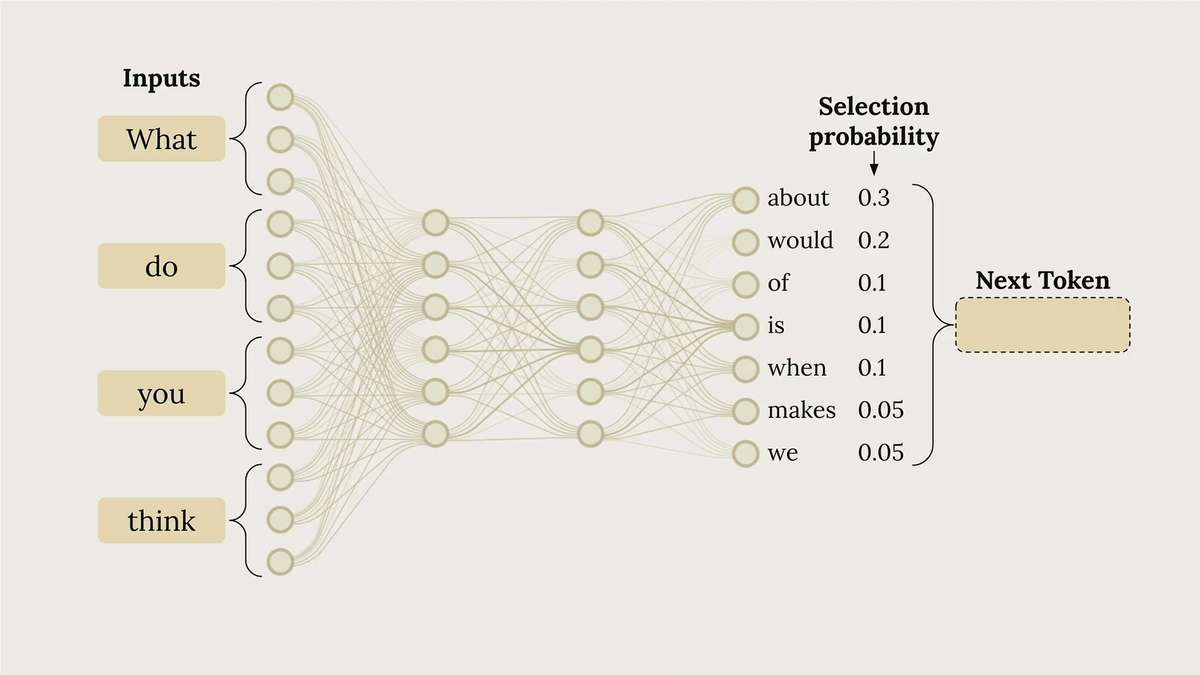

In [23]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"1px"}; margin-top: 1px;'>{""}</h3></div>"""))
display(Image(filename='Reference_Photos/temperature_1.png', embed=True))

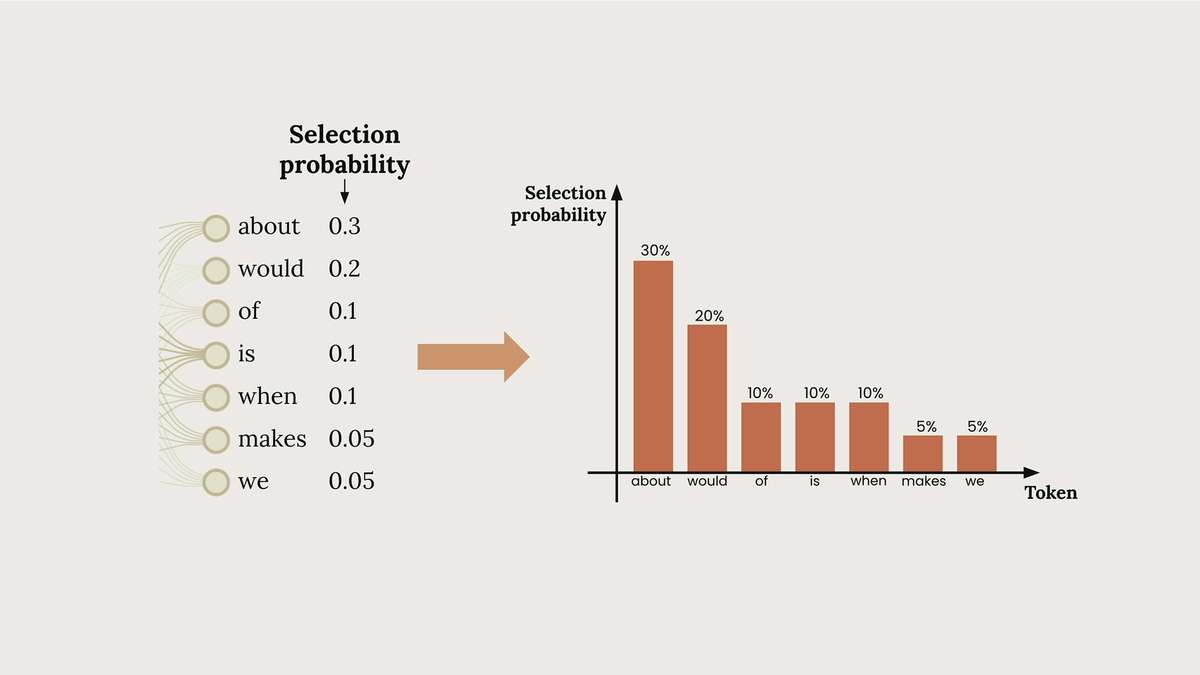

In [24]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"1px"}; margin-top: 1px;'>{""}</h3></div>"""))
display(Image(filename='Reference_Photos/temperature_2.png', embed=True))

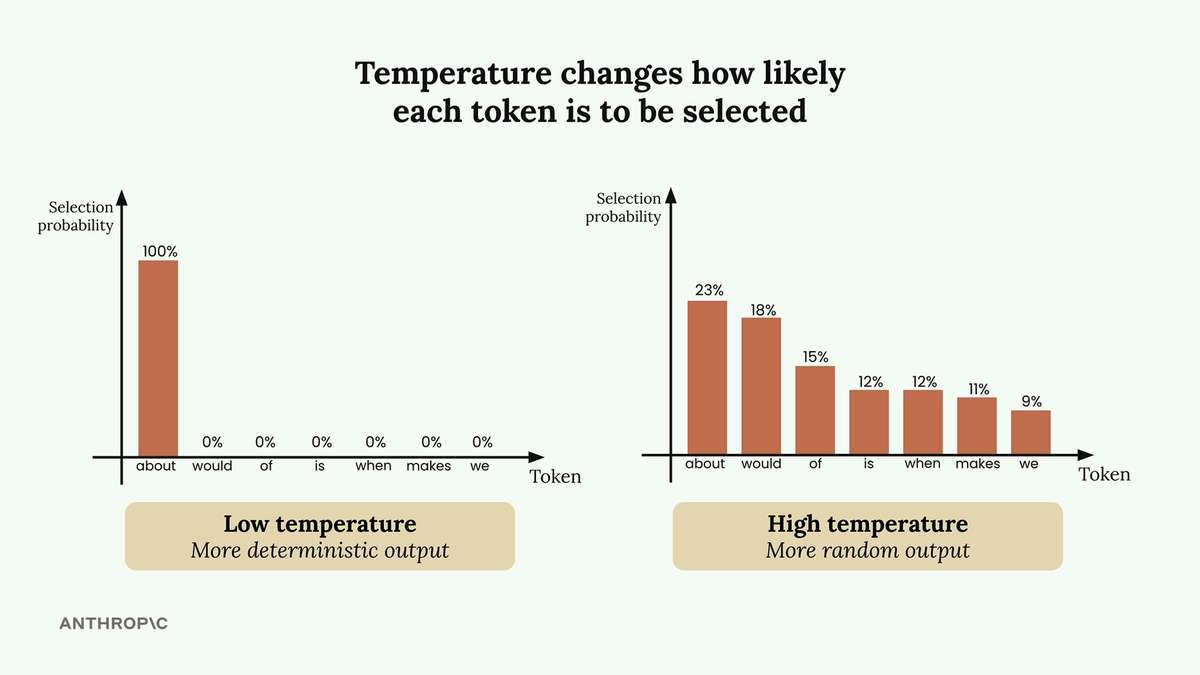

In [25]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"1px"}; margin-top: 1px;'>{""}</h3></div>"""))
display(Image(filename='Reference_Photos/temperature_3.png', embed=True))

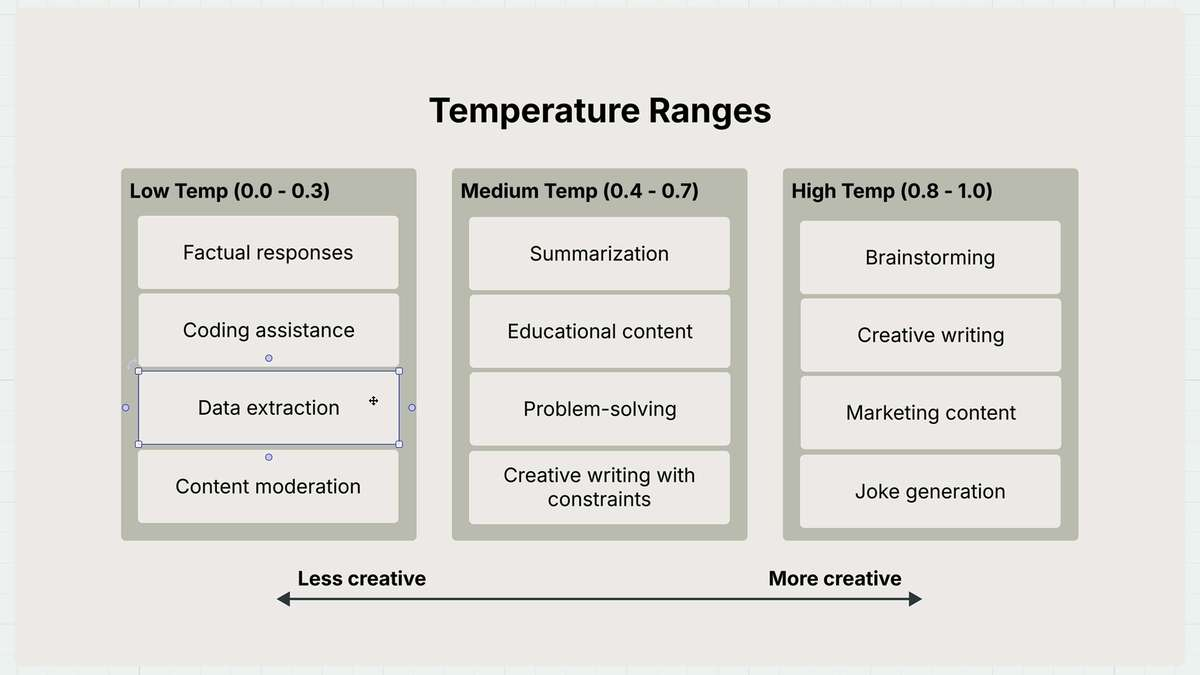

In [26]:
from IPython.display import Image, display, HTML
display(HTML(f"""<div><h3 style='text-align:left; font-size:{"1px"}; margin-top: 1px;'>{""}</h3></div>"""))
display(Image(filename='Reference_Photos/temperature_4.png', embed=True))

In [28]:
# Updating chat function to include temperature
def chat(messages, system=None, temperature=1.0):
    params = {
        "model": model,
        "max_tokens": 1000,
        "messages": messages,
        "temperature": temperature
    }
    
    if system:
        params["system"] = system
    
    message = client.messages.create(**params)
    return message.content[0].text

In [31]:
messages = []

add_user_message(messages,"Generate one sentence movie idea")

print("##### Low temperature - more predictable ####")
answer = chat(messages, temperature=0.0)
print(answer)

print("\n\n##### Low temperature - more predictable ####")
answer = chat(messages, temperature=0.0)
print(answer)

print("\n\n#### High temperature - more creative   ####")
answer = chat(messages, temperature=1.0)
print(answer)

print("\n\n#### High temperature - more creative   ####")
answer = chat(messages, temperature=1.0)
print(answer)

##### Low temperature - more predictable ####
A time-traveling janitor discovers that every mess he cleans up in the present prevents a catastrophic disaster in the future, but he only has 24 hours to clean the dirtiest building in the city before humanity's timeline collapses forever.


##### Low temperature - more predictable ####
A time-traveling janitor discovers that every mess he cleans up in the present prevents a catastrophic disaster in the future, but he only has 24 hours to clean the dirtiest building in the city before humanity's timeline collapses forever.


#### High temperature - more creative   ####
A time-traveling janitor must clean up increasingly absurd messes left by reckless time tourists before the timeline collapses entirely.


#### High temperature - more creative   ####
A time-traveling janitor discovers that every mess he cleans in the present prevents a catastrophic disaster in the future, but the building's new automated cleaning system threatens to erase h

### 40.1.1  f) Response Streaming
- So far - in the above example - we have to wait for 5-10 secs to get the full response. 
- Instead of this - we can do streaming of the response
- **RawContentBlockDeltaEvent** : This is the most important event type ... it has the incremental text
    - We can write our own code to extact the information and print.. but Anthropic SDK already has it.
- Anthropic SDK automatically handles all of this -- and gives the delta text.


In [32]:
# Checking raw event from claude
messages = []
add_user_message(messages, "Write a 1 sentence description of a fake database")

stream = client.messages.create(model = model, max_tokens = 1000, messages = messages, stream = True)

for event in stream:
    print(event)

RawMessageStartEvent(message=Message(id='msg_012mY4ei8QznxSMWQ4NiGn25', container=None, content=[], model='claude-sonnet-4-20250514', role='assistant', stop_details=None, stop_reason=None, stop_sequence=None, type='message', usage=Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=0), cache_creation_input_tokens=0, cache_read_input_tokens=0, inference_geo='not_available', input_tokens=18, output_tokens=1, server_tool_use=None, service_tier='standard')), type='message_start')
RawContentBlockStartEvent(content_block=TextBlock(citations=None, text='', type='text'), index=0, type='content_block_start')
RawContentBlockDeltaEvent(delta=TextDelta(text='F', type='text_delta'), index=0, type='content_block_delta')
RawContentBlockDeltaEvent(delta=TextDelta(text='akeDB is a lightweight in-memory database simulator that generates realistic sample data and supports', type='text_delta'), index=0, type='content_block_delta')
RawContentBlockDeltaEvent(delta=TextD

In [33]:
# using Anthropic SDK
messages = []
add_user_message(messages, "Write a 1 sentence description of a fake database")

with client.messages.stream(model = model, max_tokens = 1000, messages = messages) as stream:
    for text in stream.text_stream:
        print(text, end="")

The "GlobalSync Enterprise Database" is a revolutionary cloud-based system that automatically harmonizes data across multiple platforms while providing real-time predictive analytics and quantum-encrypted security protocols for seamless business intelligence integration.

In [39]:
# Getting final message -- that can be then stored in a databse or for logging
messages = []
add_user_message(messages, "Write a 1 sentence description of a fake database")

with client.messages.stream(model = model, max_tokens = 1000, messages = messages) as stream:
    for text in stream.text_stream:
        print(text, end="")

final_message = stream.get_final_message()
print("\n\n#### Final message ####")
print(final_message.content[0].text)

FakeDB is a lightweight Python library that generates realistic mock data for testing applications, featuring customizable schemas, relationship modeling, and export capabilities to JSON, CSV, and SQL formats.

#### Final message ####
FakeDB is a lightweight Python library that generates realistic mock data for testing applications, featuring customizable schemas, relationship modeling, and export capabilities to JSON, CSV, and SQL formats.



---

[➡ <font color="red"><b>Continue to Part 1b — Prompting, Tools & RAG</b></font>](part1b_fndmntl_prompting_tools_rag.ipynb)
